In [3]:
import cv2
import numpy as np
import matplotlib . pyplot as plt
# termination criteria
criteria = ( cv2 . TERM_CRITERIA_EPS + cv2 . TERM_CRITERIA_MAX_ITER , 30 , 0.001)
calibration_flags = cv2 . fisheye . CALIB_RECOMPUTE_EXTRINSIC + cv2 . fisheye .CALIB_FIX_SKEW
# inner size of chessboard
width = 9
height = 6
square_size = 0.025 # 0.025 meters
# prepare object points , like (0 ,0 ,0) , (1 ,0 ,0) , (2 ,0 ,0) .... ,(8 ,6 ,0)
objp = np . zeros (( height * width , 1 , 3) , np . float64 )
objp [: , 0, :2] = np . mgrid [0: width , 0: height ]. T. reshape ( -1 , 2)
objp = objp * square_size # Create real world coords . Use your metric .
# Arrays to store object points and image points from all the images .
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane .
img_width = 640
img_height = 480
image_size = ( img_width , img_height )
path = ""
image_dir = path + "pairs/"
number_of_images = 50
for i in range (1 , number_of_images ):
# read image
	
	img = cv2.imread(image_dir + "left_%02d.png" % i)
	if img is None:
		print(f"Image not found: {image_dir}left_{i:02d}.png")
		continue
	gray = cv2 . cvtColor ( img , cv2 . COLOR_BGR2GRAY )
	# Find the chess board corners
	ret , corners = cv2 . findChessboardCorners ( gray , ( width , height ) , cv2 .
	CALIB_CB_ADAPTIVE_THRESH + cv2 . CALIB_CB_FAST_CHECK + cv2 .
	CALIB_CB_NORMALIZE_IMAGE )
	Y , X , channels = img . shape
	# skip images where the corners of the chessboard are too close to the edges of the image
	if ( ret == True ):
		minRx = corners [: ,: ,0]. min ()
		maxRx = corners [: ,: ,0]. max ()
		minRy = corners [: ,: ,1]. min ()
		maxRy = corners [: ,: ,1]. max ()
		border_threshold_x = X /12
		border_threshold_y = Y /12
		x_thresh_bad = False
		y_thresh_bad = False
		if ( minRx < border_threshold_x ) :
			x_thresh_bad = True
			y_thresh_bad = False
		if ( minRy < border_threshold_y ) :
			y_thresh_bad = True
		if ( y_thresh_bad == True ) or ( x_thresh_bad == True ):
			continue
	# If found , add object points , image points ( after refining them )
	if ret == True :
		objpoints . append ( objp )
	# improving the location of points (sub - pixel )
		corners2 = cv2 . cornerSubPix ( gray , corners , (3 , 3) , ( -1 , -1) , criteria )
		imgpoints . append ( corners2 )
	# Draw and display the corners
	# Show the image to see if pattern is found ! imshow function .
		# cv2 . drawChessboardCorners ( img , ( width , height ) , corners2 , ret )
		# cv2 . imshow (" Corners ", img )
		# cv2 . waitKey (5)
	else :
		print (" Chessboard couldn ’t detected . Image pair : ", i)
		continue


=== Parametry kamery (lewa) ===
RMS reprojekcji: 0.114629
Macierz K (parametry wewnętrzne):
 [[335.39124594   0.         345.29455183]
 [  0.         335.22283549 232.92700067]
 [  0.           0.           1.        ]]
Współczynniki dystorsji D: [-0.02430673 -0.018878    0.02584017 -0.01508828]


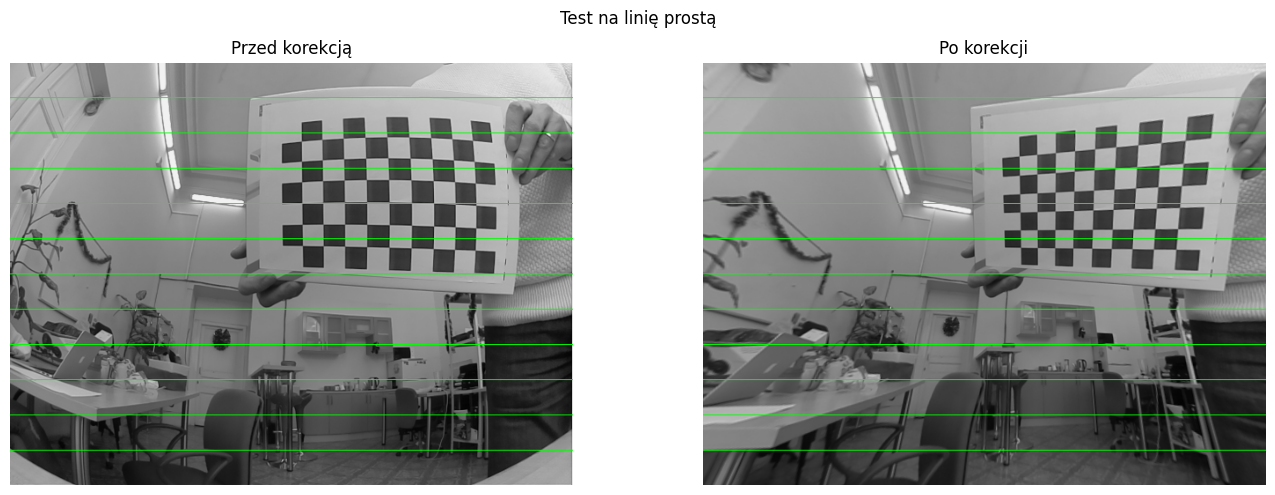

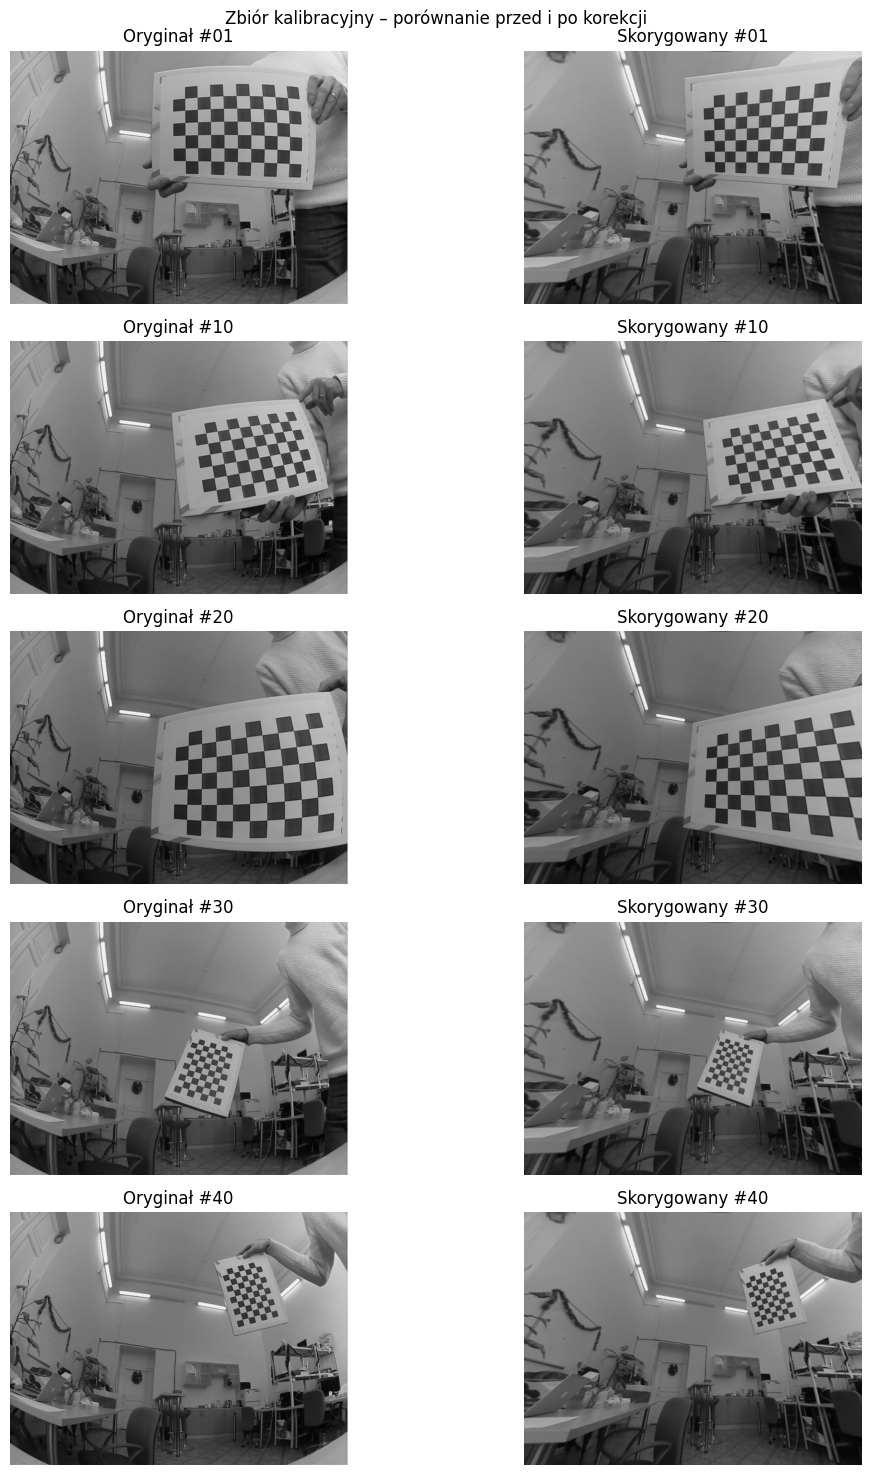

In [8]:
# --- Ćwiczenie 11.1: Kalibracja pojedynczej kamery ---
%matplotlib inline

K = np.zeros((3, 3))
D = np.zeros((4, 1))
rvecs, tvecs = [], []

rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
    objpoints, imgpoints, image_size, K, D, rvecs, tvecs,
    calibration_flags,
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6),
)

print("=== Parametry kamery (lewa) ===")
print(f"RMS reprojekcji: {rms:.6f}")
print("Macierz K (parametry wewnętrzne):\n", K)
print("Współczynniki dystorsji D:", D.ravel())

new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    K, D, image_size, np.eye(3), balance=0.0
)
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, D, np.eye(3), new_K, image_size, cv2.CV_16SC2
)


def undistort(img):
    return cv2.remap(
        img, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
    )


def draw_horizontal_lines(img, step=40, color=(0, 255, 0)):
    out = img.copy()
    for y in range(step, img.shape[0], step):
        cv2.line(out, (0, y), (img.shape[1], y), color, 1)
    return out


# Test korekcji na jednym obrazie (linie poziome)
test_idx = 1
test_img = cv2.imread(f"{image_dir}left_{test_idx:02d}.png")
test_undist = undistort(test_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(draw_horizontal_lines(test_img), cv2.COLOR_BGR2RGB))
axes[0].set_title("Przed korekcją")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(draw_horizontal_lines(test_undist), cv2.COLOR_BGR2RGB))
axes[1].set_title("Po korekcji")
axes[1].axis("off")
plt.suptitle("Test na linię prostą")
plt.tight_layout()
plt.show()

# Korekcja całego zbioru – porównanie przed/po (wybrane klatki)
sample_ids = [1, 10, 20, 30, 40]
fig, axes = plt.subplots(len(sample_ids), 2, figsize=(12, 3 * len(sample_ids)))
for row, idx in enumerate(sample_ids):
    img = cv2.imread(f"{image_dir}left_{idx:02d}.png")
    if img is None:
        continue
    corrected = undistort(img)
    axes[row, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"Oryginał #{idx:02d}")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f"Skorygowany #{idx:02d}")
    axes[row, 1].axis("off")
plt.suptitle("Zbiór kalibracyjny – porównanie przed i po korekcji")
plt.tight_layout()
plt.show()

Pary stereo do kalibracji: 44
RMS lewa: 0.114056, RMS prawa: 0.110781
RMS kalibracji stereo: 0.144270


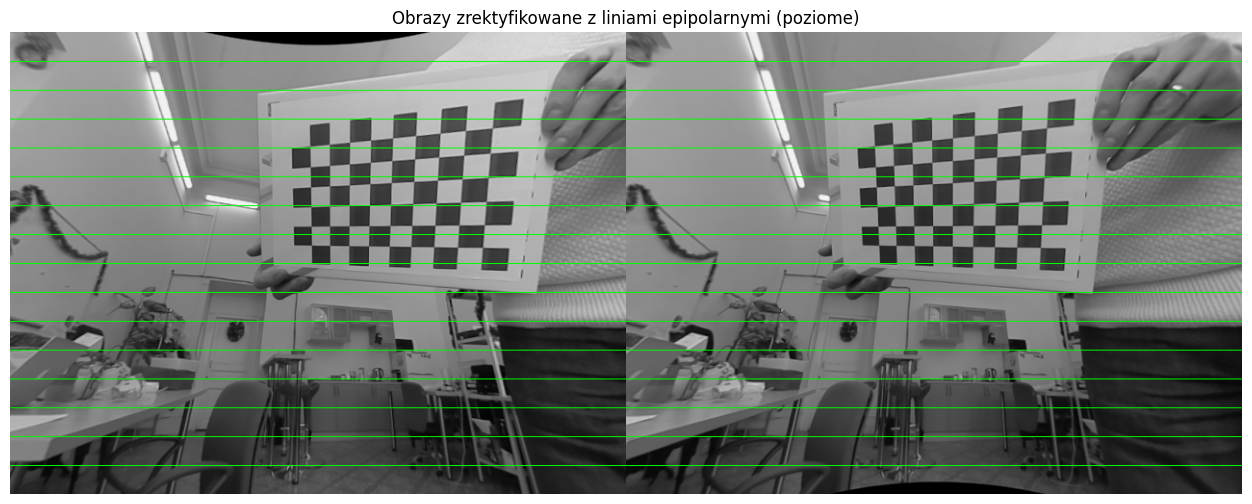

In [6]:
# --- Ćwiczenie 11.2: Kalibracja i rektyfikacja układu stereo ---
objpoints_stereo, imgpointsLeft, imgpointsRight = [], [], []

for i in range(1, number_of_images):
    img_l = cv2.imread(f"{image_dir}left_{i:02d}.png")
    img_r = cv2.imread(f"{image_dir}right_{i:02d}.png")
    if img_l is None or img_r is None:
        continue

    gray_l = cv2.cvtColor(img_l, cv2.COLOR_BGR2GRAY)
    gray_r = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
    flags_cb = (
        cv2.CALIB_CB_ADAPTIVE_THRESH
        + cv2.CALIB_CB_FAST_CHECK
        + cv2.CALIB_CB_NORMALIZE_IMAGE
    )
    ret_l, corners_l = cv2.findChessboardCorners(gray_l, (width, height), flags_cb)
    ret_r, corners_r = cv2.findChessboardCorners(gray_r, (width, height), flags_cb)
    if not (ret_l and ret_r):
        continue

    Y, X = img_l.shape[:2]
    border_x, border_y = X / 12, Y / 12
    if (
        corners_l[:, :, 0].min() < border_x
        or corners_l[:, :, 1].min() < border_y
        or corners_r[:, :, 0].min() < border_x
        or corners_r[:, :, 1].min() < border_y
    ):
        continue

    objpoints_stereo.append(objp)
    imgpointsLeft.append(cv2.cornerSubPix(gray_l, corners_l, (3, 3), (-1, -1), criteria))
    imgpointsRight.append(cv2.cornerSubPix(gray_r, corners_r, (3, 3), (-1, -1), criteria))

print(f"Pary stereo do kalibracji: {len(objpoints_stereo)}")


def fisheye_calibrate(obj_pts, img_pts):
    k = np.zeros((3, 3))
    d = np.zeros((4, 1))
    rv, tv = [], []
    err, k, d, rv, tv = cv2.fisheye.calibrate(
        obj_pts, img_pts, image_size, k, d, rv, tv,
        calibration_flags,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6),
    )
    return err, k, d


rms_left, K_left, D_left= fisheye_calibrate(objpoints_stereo, imgpointsLeft)
rms_right, K_right, D_right= fisheye_calibrate(objpoints_stereo, imgpointsRight)
print(f"RMS lewa: {rms_left:.6f}, RMS prawa: {rms_right:.6f}")

imgpointsLeft_arr = np.asarray(imgpointsLeft, dtype=np.float64)
imgpointsRight_arr = np.asarray(imgpointsRight, dtype=np.float64)

rms_stereo, _, _, _, _, rotationMatrix, translationVector = cv2.fisheye.stereoCalibrate(
    objpoints_stereo,
    imgpointsLeft_arr,
    imgpointsRight_arr,
    K_left,
    D_left,
    K_right,
    D_right,
    image_size,
    None,
    None,
    cv2.CALIB_FIX_INTRINSIC,
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.01),
)
print(f"RMS kalibracji stereo: {rms_stereo:.6f}")

R1 = np.zeros((3, 3))
R2 = np.zeros((3, 3))
P1 = np.zeros((3, 4))
P2 = np.zeros((3, 4))
Q = np.zeros((4, 4))

leftRectification, rightRectification, leftProjection, rightProjection, disparityToDepthMap = (
    cv2.fisheye.stereoRectify(
        K_left,
        D_left,
        K_right,
        D_right,
        image_size,
        rotationMatrix,
        translationVector,
        cv2.CALIB_ZERO_DISPARITY,
        R1,
        R2,
        P1,
        P2,
        Q,
    )
)

map1_left, map2_left = cv2.fisheye.initUndistortRectifyMap(
    K_left, D_left, leftRectification, leftProjection, image_size, cv2.CV_16SC2
)
map1_right, map2_right = cv2.fisheye.initUndistortRectifyMap(
    K_right, D_right, rightRectification, rightProjection, image_size, cv2.CV_16SC2
)


def rectify_stereo(img_l, img_r):
    dst_l = cv2.remap(img_l, map1_left, map2_left, cv2.INTER_LINEAR)
    dst_r = cv2.remap(img_r, map1_right, map2_right, cv2.INTER_LINEAR)
    return dst_l, dst_r


def stack_with_epipolar_lines(img_l, img_r, step=30):
    h = max(img_l.shape[0], img_r.shape[0])
    w = img_l.shape[1] + img_r.shape[1]
    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    canvas[: img_l.shape[0], : img_l.shape[1]] = img_l
    canvas[: img_r.shape[0], img_l.shape[1] :] = img_r
    for y in range(step, h, step):
        cv2.line(canvas, (0, y), (w, y), (0, 255, 0), 1)
    return canvas


rect_pair_idx = 1
img_l = cv2.imread(f"{image_dir}left_{rect_pair_idx:02d}.png")
img_r = cv2.imread(f"{image_dir}right_{rect_pair_idx:02d}.png")
rect_l, rect_r = rectify_stereo(img_l, img_r)

plt.figure(figsize=(16, 6))
plt.imshow(cv2.cvtColor(stack_with_epipolar_lines(rect_l, rect_r), cv2.COLOR_BGR2RGB))
plt.title("Obrazy zrektyfikowane z liniami epipolarnymi (poziome)")
plt.axis("off")
plt.show()

In [11]:
# --- Ćwiczenie 11.3: Mapa dysparycji (BM i SGBM) przed i po kalibracji ---
stereo_stitched = cv2.imread("example/example0.jpg")
if stereo_stitched is None:
    raise FileNotFoundError("Brak pliku example/example0.jpg – uruchom notebook z katalogu lab11/")

h, w = stereo_stitched.shape[:2]
mid = w // 2
img_l_raw = stereo_stitched[:, :mid].copy()
img_r_raw = stereo_stitched[:, mid:].copy()

# skalowanie do rozdzielczości kalibracji (mapy rektyfikacji: 640×480)
resize_to = (image_size[0], image_size[1])
img_l_raw = cv2.resize(img_l_raw, resize_to)
img_r_raw = cv2.resize(img_r_raw, resize_to)

rect_l_ex, rect_r_ex = rectify_stereo(img_l_raw, img_r_raw)


def normalize_disparity(disp, valid_mask=None):
    disp_float = disp.astype(np.float32)
    if valid_mask is None:
        valid = disp_float > 0
    else:
        valid = valid_mask
    if not np.any(valid):
        return np.zeros(disp.shape, dtype=np.uint8)
    vmin, vmax = disp_float[valid].min(), disp_float[valid].max()
    norm = np.zeros_like(disp_float, dtype=np.uint8)
    norm[valid] = ((disp_float[valid] - vmin) / (vmax - vmin + 1e-6) * 255).astype(np.uint8)
    return norm


def compute_disparities(gray_l, gray_r, num_disp=64, block_size=5):
    num_disp = max(16, (num_disp // 16) * 16)
    bm = cv2.StereoBM_create(numDisparities=num_disp, blockSize=15)
    disp_bm = bm.compute(gray_l, gray_r)

    sgbm = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=num_disp,
        blockSize=block_size,
        P1=8 * 3 * block_size ** 2,
        P2=32 * 3 * block_size ** 2,
        disp12MaxDiff=1,
        uniquenessRatio=10,
        speckleWindowSize=100,
        speckleRange=32,
    )
    disp_sgbm = sgbm.compute(gray_l, gray_r)
    return disp_bm, disp_sgbm


def disparity_heatmap(disp):
    norm = normalize_disparity(disp)
    return cv2.applyColorMap(norm, cv2.COLORMAP_HOT)


pairs = [
    ("Przed kalibracją", img_l_raw, img_r_raw),
    ("Po kalibracji / rektyfikacji", rect_l_ex, rect_r_ex),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for row, (title, left, right) in enumerate(pairs):
    gray_l = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
    gray_r = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)
    disp_bm, disp_sgbm = compute_disparities(gray_l, gray_r)

    axes[row, 0].imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{title}\nLewy")
    axes[row, 1].imshow(cv2.cvtColor(right, cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title("Prawy")
    axes[row, 2].imshow(disparity_heatmap(disp_bm))
    axes[row, 2].set_title("StereoBM")
    axes[row, 3].imshow(disparity_heatmap(disp_sgbm))
    axes[row, 3].set_title("StereoSGBM")
    axes[row, 4].imshow(
        cv2.cvtColor(stack_with_epipolar_lines(left, right, step=50), cv2.COLOR_BGR2RGB)
    )
    axes[row, 4].set_title("Para + linie")
    for col in range(5):
        axes[row, col].axis("off")

plt.suptitle("Mapy dysparycji – example/example0.jpg (przed i po kalibracji)")
plt.tight_layout()
plt.show()

[ WARN:0@5034.151] global loadsave.cpp:278 findDecoder imread_('example/example1.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'
